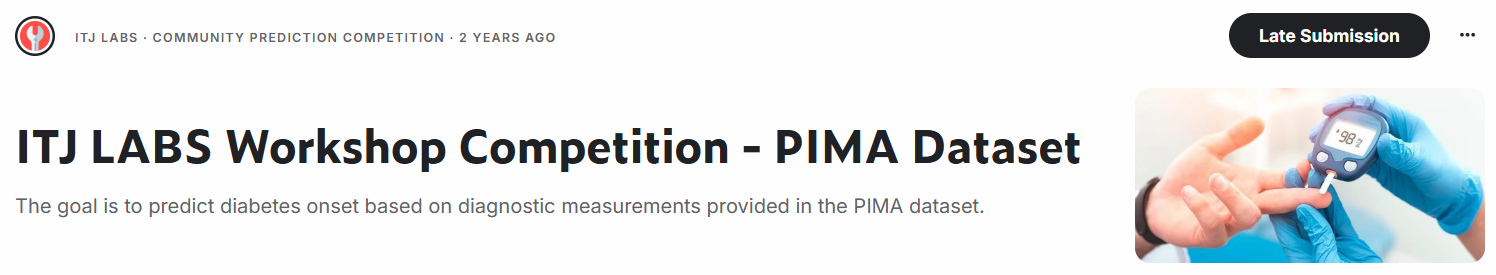
* kaggle : https://www.kaggle.com/competitions/itj-labs-workshop-competition-pima-dataset

u<pre>Pregnancies: Number of times the patient was pregnant.
Glucose: Plasma glucose concentration over a 2-hour oral glucose tolerance test.
BloodPressure: Diastolic blood pressure (mm Hg).
SkinThickness: Triceps skinfold thickness (mm).
Insulin: 2-hour serum insulin (μU/mL).
BMI: Body mass index, calculated as weight in kg divided by height in m².
DiabetesPedigreeFunction: A function that scores the likelihood of diabetes based on family history.
Age: Patient’s age in years.
Outcome: The target variable in train.csv, indicating whether the patient has diabetes (1) or not (0).

In [1]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split           #---- 문제답 분리

from sklearn.linear_model import LogisticRegression             #---- 분류모델(선형모델)
from sklearn.ensemble import RandomForestClassifier             #---- 분류모델(트리모델)   
from sklearn.ensemble import VotingClassifier, VotingRegressor  #---- 분류모델(앙상블)  

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve #---- 평가 메트릭스
from sklearn.metrics import roc_auc_score, roc_curve     #---- 평가 메트릭스
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate  #----교차검증

from sklearn.preprocessing import LabelEncoder, OneHotEncoder                       #-----인코딩(글자->숫자변경)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler        #-----정규화(스케일링)
from sklearn.decomposition import PCA                                               #-----차원축소


# **[1] Data Load**

In [2]:
train = pd.read_csv("../datas/pima/train.csv")   #, parse_dates=['datetime'])
test  = pd.read_csv("../datas/pima/test.csv") 

In [3]:
train.shape, test.shape

((616, 9), (152, 8))

* <b>컬럼 이름 소문자

In [4]:
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()

In [5]:
train = train.rename(columns={'bloodpressure':'blood',
                              'skinthickness' : 'skin',
                              'diabetespedigreefunction': 'diabet'})
test = test.rename(columns={'bloodpressure':'blood',
                              'skinthickness' : 'skin',
                              'diabetespedigreefunction': 'diabet'})

In [6]:
train.head(2)

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age,outcome
0,2,90,60,0,0,23.5,0.191,25,0
1,2,92,52,0,0,30.1,0.141,22,0


In [7]:
test.head(2)

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age
0,7,106,92,18,0,22.7,0.235,48
1,2,90,68,42,0,38.2,0.503,27


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  616 non-null    int64  
 1   glucose      616 non-null    int64  
 2   blood        616 non-null    int64  
 3   skin         616 non-null    int64  
 4   insulin      616 non-null    int64  
 5   bmi          616 non-null    float64
 6   diabet       616 non-null    float64
 7   age          616 non-null    int64  
 8   outcome      616 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 43.4 KB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  152 non-null    int64  
 1   glucose      152 non-null    int64  
 2   blood        152 non-null    int64  
 3   skin         152 non-null    int64  
 4   insulin      152 non-null    int64  
 5   bmi          152 non-null    float64
 6   diabet       152 non-null    float64
 7   age          152 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 9.6 KB


* <font color=red><b>결측없다
* <font color=red><b>글자없다

# **[2] 1차점수 : 우선 점수만 보자**

## **공통함수**

In [10]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model =  RandomForestClassifier (
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    

In [11]:
def myscore222(df,  model=None, MY_TARGET="outcome") :
    X = df.drop(columns=['outcome'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.2, random_state=1234, shuffle=True)

    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )
    
    #-------------------------------------------------proba
    # proba = model.predict_proba(X_test3)
    # proba_p = proba[:,1]
    #print(proba_p)
    
    # precision, recall, th = precision_recall_curve(y_test3, proba_p)
    # #print(precision, recall, th)
    # #print(len(precision), len(recall), len(th))

    # plt.figure(figsize=(8,2))
    # plt.plot(th, precision[:len(th)], label="precision")
    # plt.plot(th, recall[:len(th)], label="recall")
    # plt.legend()
    # plt.title("precision_reacall_curv")
    # plt.show()

    #-------------------------------------------------proba : roc
    # roc = roc_auc_score(y_test3, proba_p)
    # print( f"roc auc score : {roc:.4f}" )
    # fpr, tpr, th = roc_curve(y_test3, proba_p)

    # plt.figure(figsize=(8,2))
    # plt.plot(fpr, tpr)
    # plt.plot([0, 1], [0, 1], 'k--')
    # plt.title("roc_curve")
    # plt.xlabel("False Positive Rate (FPR)")
    # plt.ylabel("True Positive Rate (TPR) == recall")
    # plt.show()       
    
    return model

## **1차점수**
* f1 : 0.5872

In [12]:
res =  myscore222(train)

RandomForestClassifier
acc : 0.7258  f1 : 0.5750  precision : 0.6389  recall : 0.5227
[[67 13]
 [21 23]]


# **[3] EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도(왜도,첨도,정규분포)

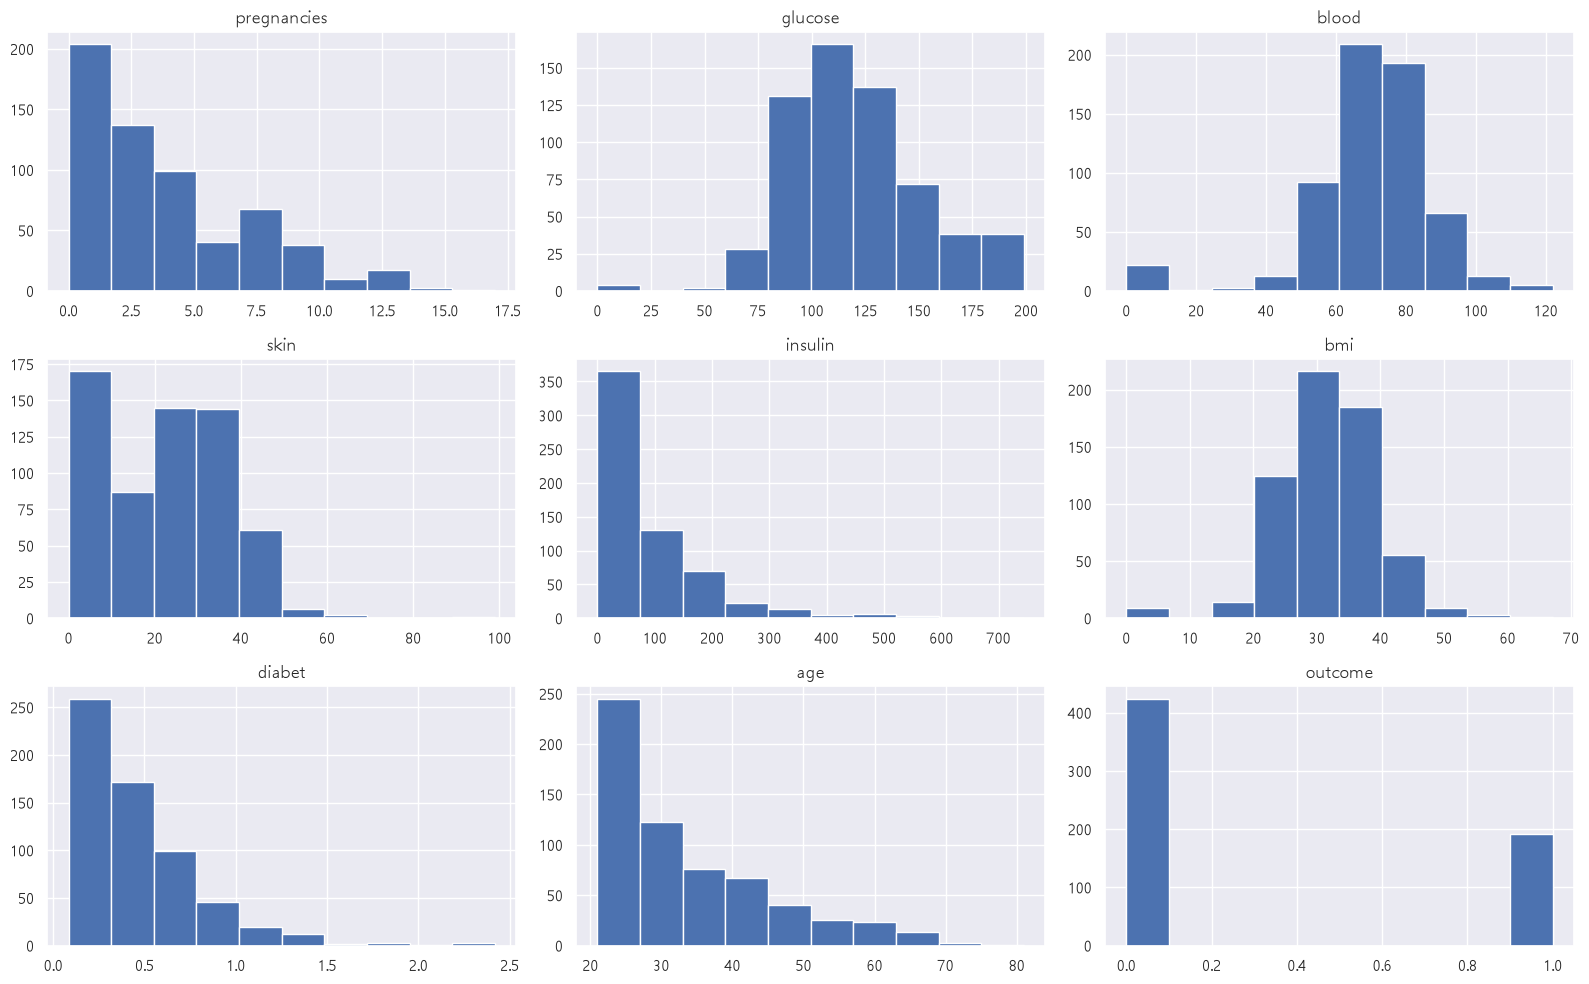

In [13]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

## 타겟분포도 : outcome

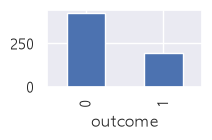

In [14]:
plt.figure(figsize=(2, 1))
train['outcome'].value_counts().plot(kind='bar')
plt.show()

## 결측여부

In [15]:
train.isna().sum()

pregnancies    0
glucose        0
blood          0
skin           0
insulin        0
bmi            0
diabet         0
age            0
outcome        0
dtype: int64

## 1차 이상치 0 데이터 처리
* **0데이터 --> 각 컬럼별로 outcome(정상/비정상) 그룹 평균**
* <font color=red><b>test에는 outcome이 없다. 그룹평균으로 채우기
* glucose , blood , skin , insulin, bmi 
* (diabet)가족력이 전혀 없어도 0이 아니라 0.078 같은 양수의 최솟값	  	 

###  각 컬럼별로 (정상/비정상) 그룹 평균

In [16]:
for col in train.columns : 
    cnt = train[train[col] == 0][col].count()
    print(f"{col} \t {cnt}")

pregnancies 	 92
glucose 	 4
blood 	 22
skin 	 166
insulin 	 285
bmi 	 9
diabet 	 0
age 	 0
outcome 	 424


In [17]:
mean0 = train[(train['outcome'] == 0) & (train['glucose'] != 0)]['glucose'].mean()
mean1 = train[(train['outcome'] == 1) & (train['glucose'] != 0)]['glucose'].mean()
print( mean0, mean1 )

110.58194774346794 143.60732984293193


### **0을 평균값으로 채우기**

* **0을 NaN으로 변경 후**

In [18]:
for col in ['glucose' , 'blood' , 'skin' , 'insulin', 'bmi'] : 
    train[col] = train[col].replace( 0,  np.nan)

In [19]:
traincp = train.copy()

In [20]:
traincp.isna().sum()

pregnancies      0
glucose          4
blood           22
skin           166
insulin        285
bmi              9
diabet           0
age              0
outcome          0
dtype: int64

In [21]:
traincp.groupby('outcome')['blood'].mean()

outcome
0    70.788835
1    74.994505
Name: blood, dtype: float64

* **방법1) train.loc[ 줄(조건절) , 칸 ] = value**

In [22]:
s = traincp.groupby('outcome')['blood'].mean()
print( s.values[0] )
print( s.values[1] )

70.78883495145631
74.99450549450549


In [23]:
mean0 = traincp[ (traincp['outcome']==0) & (traincp['blood']>0)]['blood'].mean() 
mean1 = traincp[ (traincp['outcome']==1) & (traincp['blood']>0)]['blood'].mean() 
print(mean0)
print(mean1)

70.78883495145631
74.99450549450549


In [24]:
traincp.loc[ (traincp['outcome']==0) & (traincp['blood']>0), 'blood'] = mean0
traincp.loc[ (traincp['outcome']==1) & (traincp['blood']>0), 'blood'] = mean1

* **방법2) fillna()**

In [25]:
traincp = train.copy()

In [26]:
traincp.groupby('outcome')['blood'].mean()

outcome
0    70.788835
1    74.994505
Name: blood, dtype: float64

In [27]:
for col in ['glucose' , 'blood' , 'skin' , 'insulin', 'bmi'] : 
    #traincp['blood'] = traincp['blood'].fillna( traincp.groupby('outcome')['blood'].transform('mean')  )
    traincp[col] = traincp[col].fillna( traincp.groupby('outcome')[col].transform('mean')  )

In [28]:
traincp.isna().sum()

pregnancies    0
glucose        0
blood          0
skin           0
insulin        0
bmi            0
diabet         0
age            0
outcome        0
dtype: int64

* **원본적용**

In [29]:
# for col in ['glucose' , 'blood' , 'skin' , 'insulin', 'bmi'] : 
#     train[col] = train[col].replace( 0,  np.nan)
#     train[col] = train[col].fillna( train.groupby('outcome')[col].transform('mean')  )

#     #--------- test에는 outcome이 없다... 사용불가 코드 ------------------
#     test[col] = test[col].replace( 0,  np.nan)
#     test[col] = test[col].fillna( test.groupby('outcome')[col].transform('mean')  )   

In [30]:
train['blood'].mean()

np.float64(72.07744107744108)

In [31]:
for col in ['glucose' , 'blood' , 'skin' , 'insulin', 'bmi'] : 
    train[col] = train[col].replace( 0,  np.nan)
    test[col]  = test[col].replace( 0,  np.nan)

    # train은 outcome별 평균으로 채우기
    train[col] = train[col].fillna(train.groupby('outcome')[col].transform('mean') )
    
    # test는 train의 outcome별 평균들을 평균내서 채우기 (test엔 outcome이 없으므로)
    test[col] = test[col].fillna( train.groupby('outcome')[col].transform('mean') )

### **2차점수**
* f1 : 0.5872
* f1 : 0.8706

In [32]:
model =  myscore222(train)

RandomForestClassifier
acc : 0.9113  f1 : 0.8706  precision : 0.9024  recall : 0.8409
[[76  4]
 [ 7 37]]


In [33]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v00.csv', index=False)

## **상관분석**

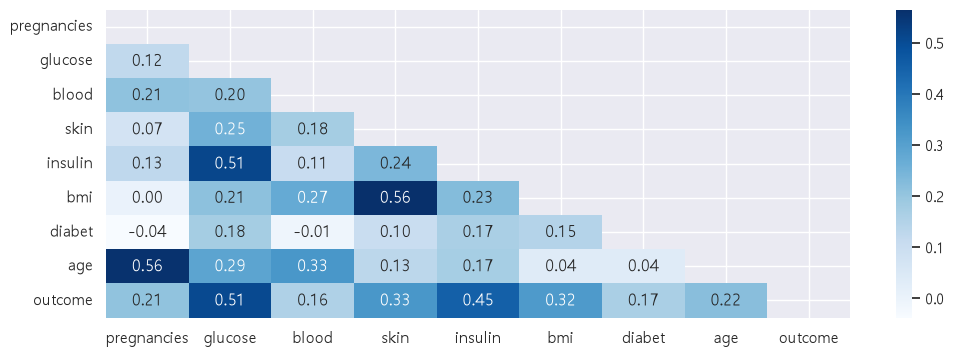

In [34]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(method='pearson'), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

* glucose, insulin

## 2차 이상치 : outlier 제거

<pre>
glucose        :  공복 후 측정한 혈당이 126 mg/dL 이상                       : 126
bloodpressure  : 고혈압은 수축기 혈압이 140mmHg 이상,확장기 혈압이 90mmHg 이상 : 90
skinthickness  : 12.72 ± 7.39                                              : 20
insulin	       :  2.6~24.9(uU/mL)   2시간 후 22~79(uU/mL)                   : 25 ~
bmi       	:  25kg/m² 이상부터 비만                                     : 30
diabet	       : 유전력의크기???
pregnancies    : 다태 임신                                                  : 4~5

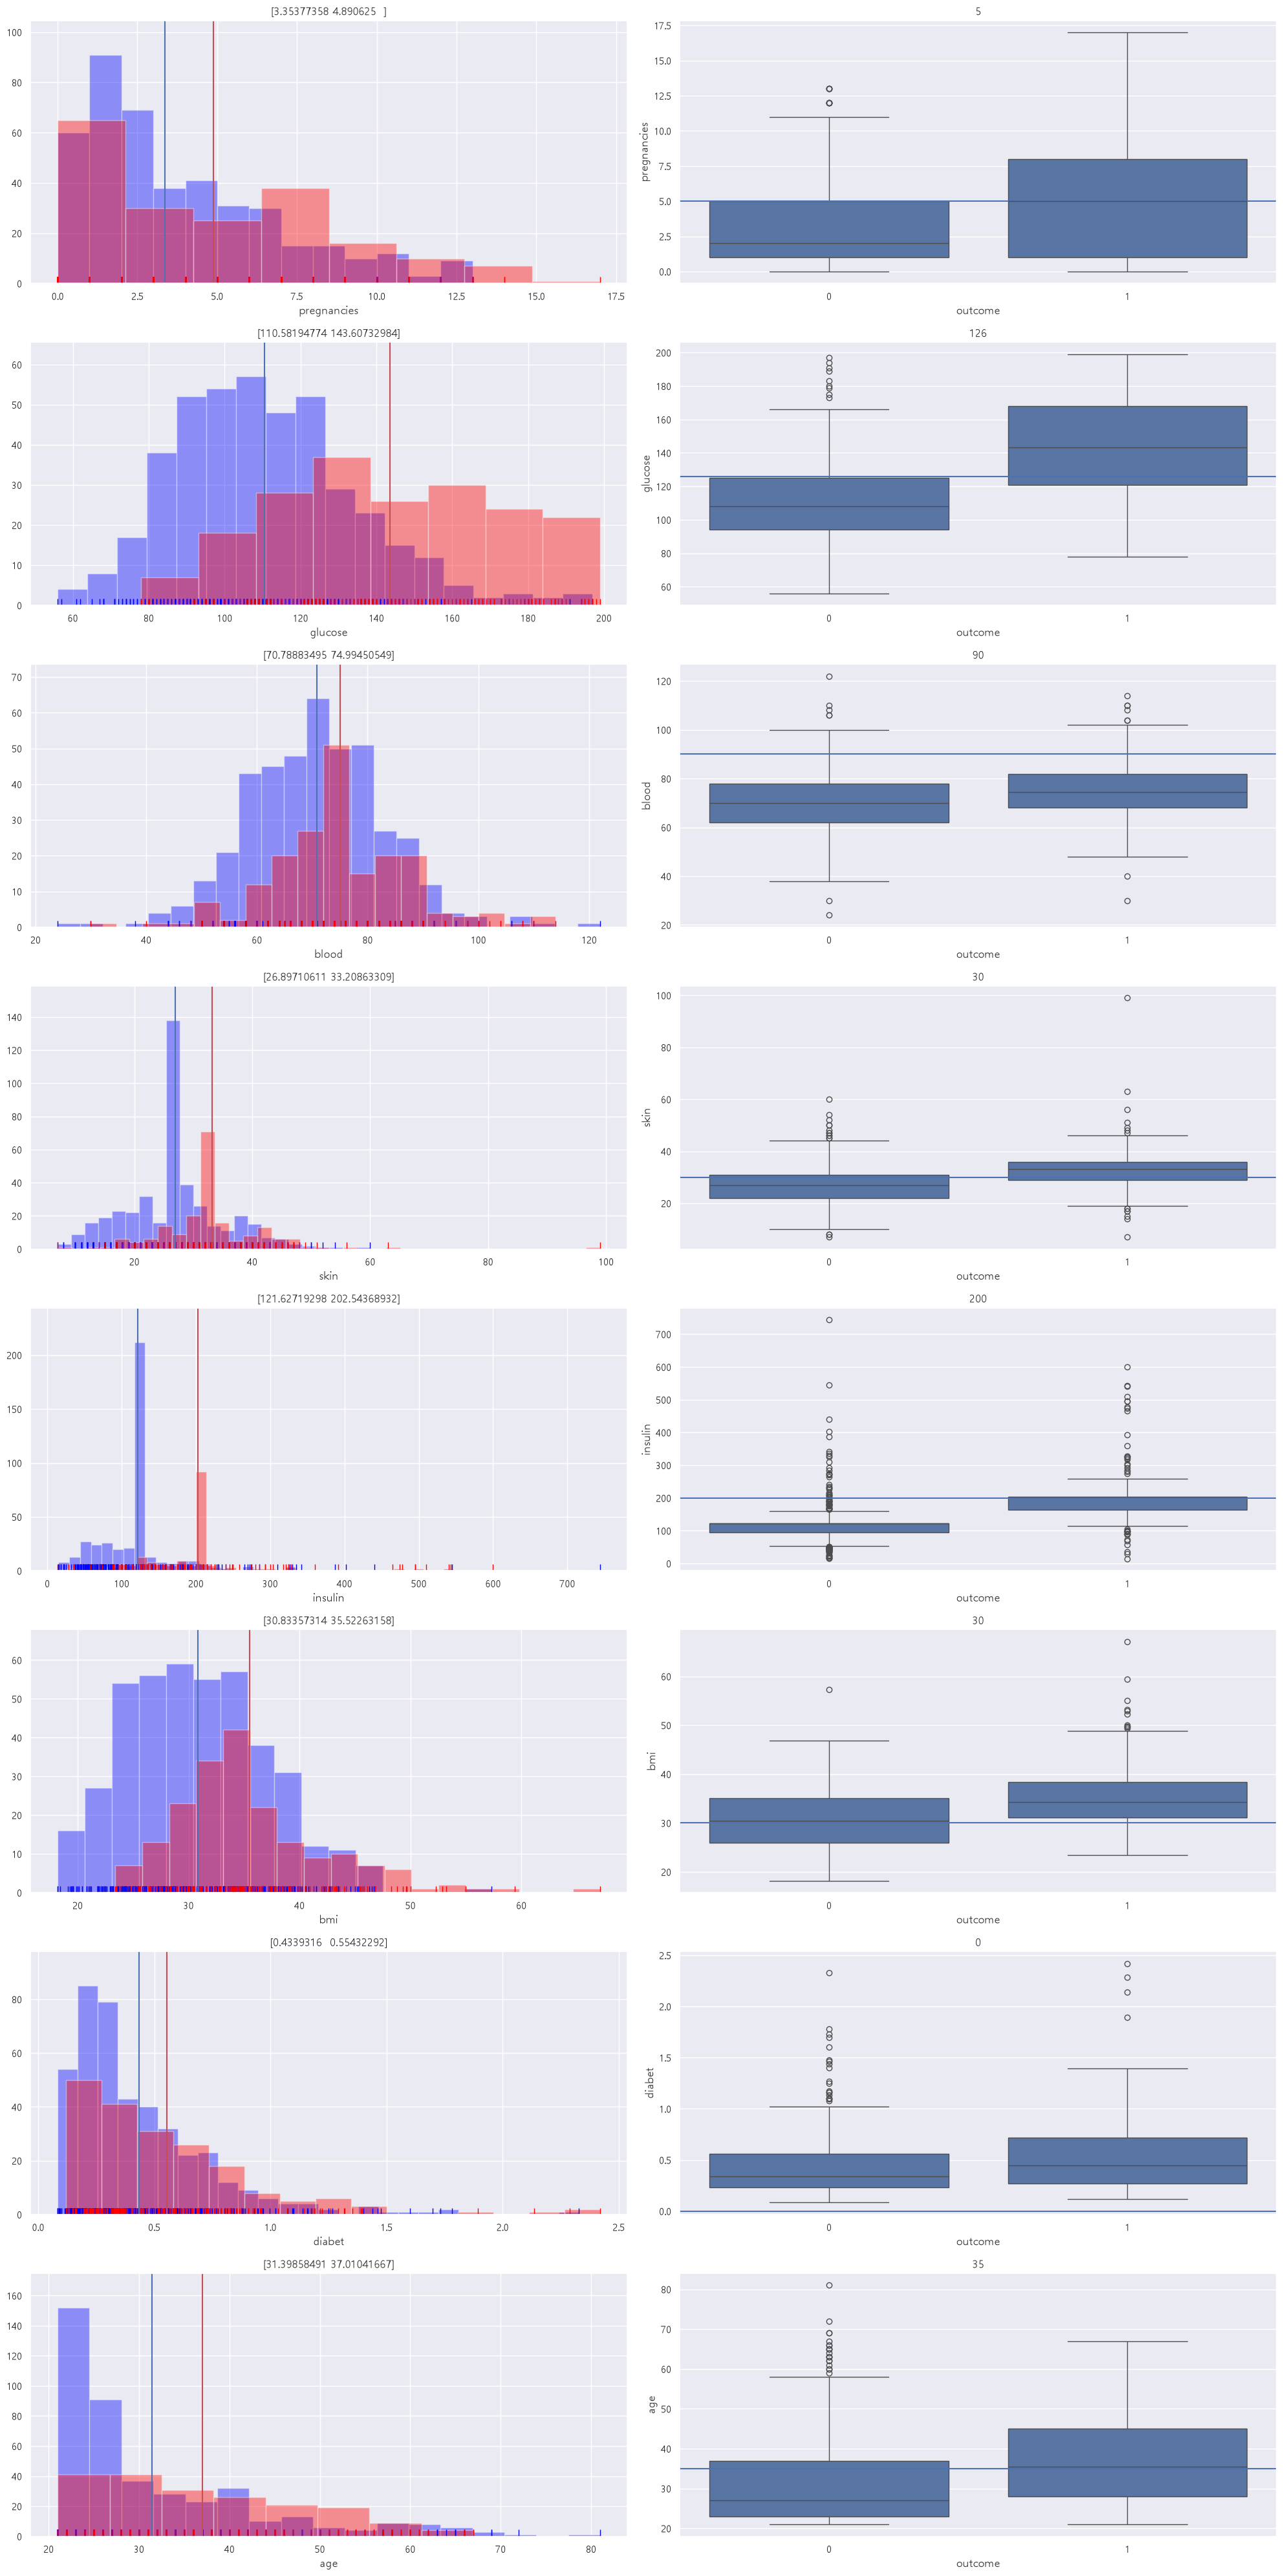

In [35]:
cols = ['pregnancies', 'glucose', 'blood', 'skin', 'insulin', 'bmi', 'diabet', 'age']
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(20, 40))
nomal_val = [5, 126, 90,30, 200, 30, 0, 35]

for i in range(len(cols)):
    col = cols[i]
    sns.distplot(train[train['outcome']==0][col]   , kde=False, rug=True, color="blue", fit_kws={"color":"#E48E58"},label="정상"  ,ax=axes[i][0])
    sns.distplot(train[train['outcome']==1][col]   , kde=False, rug=True, color="red", fit_kws={"color":"#3333FF"},label="당뇨"  ,ax=axes[i][0])
    axes[i][0].axvline(train.groupby('outcome')[col].mean().values[0], color='b')
    axes[i][0].axvline(train.groupby('outcome')[col].mean().values[1], color='r')
    axes[i][0].set_title(f"{train.groupby('outcome')[col].mean().values}")

    sns.boxplot(x="outcome",     y=col, data=train,  ax=axes[i][1])
    axes[i][1].axhline(nomal_val[i], color='b')
    axes[i][1].set_title(f"{nomal_val[i]}")

plt.tight_layout()
plt.show()


### glucosine

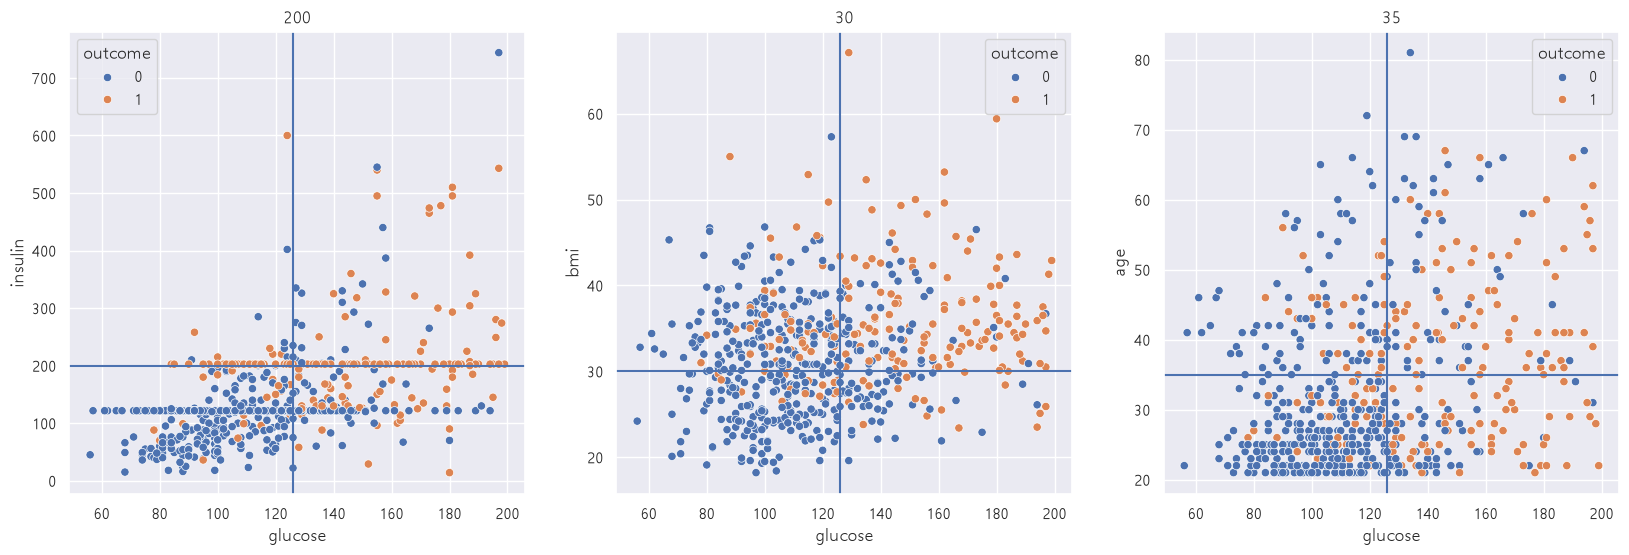

In [36]:
#cols = ['pregnancies', 'glucose', 'blood', 'skin', 'insulin', 'bmi', 'diabet', 'age']
nomal_val = [5, 126, 90,30, 200, 30, 0, 35]

sub_cols = ["insulin", "bmi", "age"]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.scatterplot(x="glucose", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[1], color='b')  #---glucose
axes[0].axhline(nomal_val[4], color='b')  #---insulin
axes[0].set_title(f"{nomal_val[4]}")

sns.scatterplot(x="glucose", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[1], color='b')  #---glucose
axes[1].axhline(nomal_val[5], color='b')  #---bmi
axes[1].set_title(f"{nomal_val[5]}")

sns.scatterplot(x="glucose", y=sub_cols[2], data=train, hue="outcome",ax=axes[2])
axes[2].axvline(nomal_val[1], color='b')   #---glucose
axes[2].axhline(nomal_val[7], color='b')   #---age
axes[2].set_title(f"{nomal_val[7]}")

plt.show()

### blood & skin

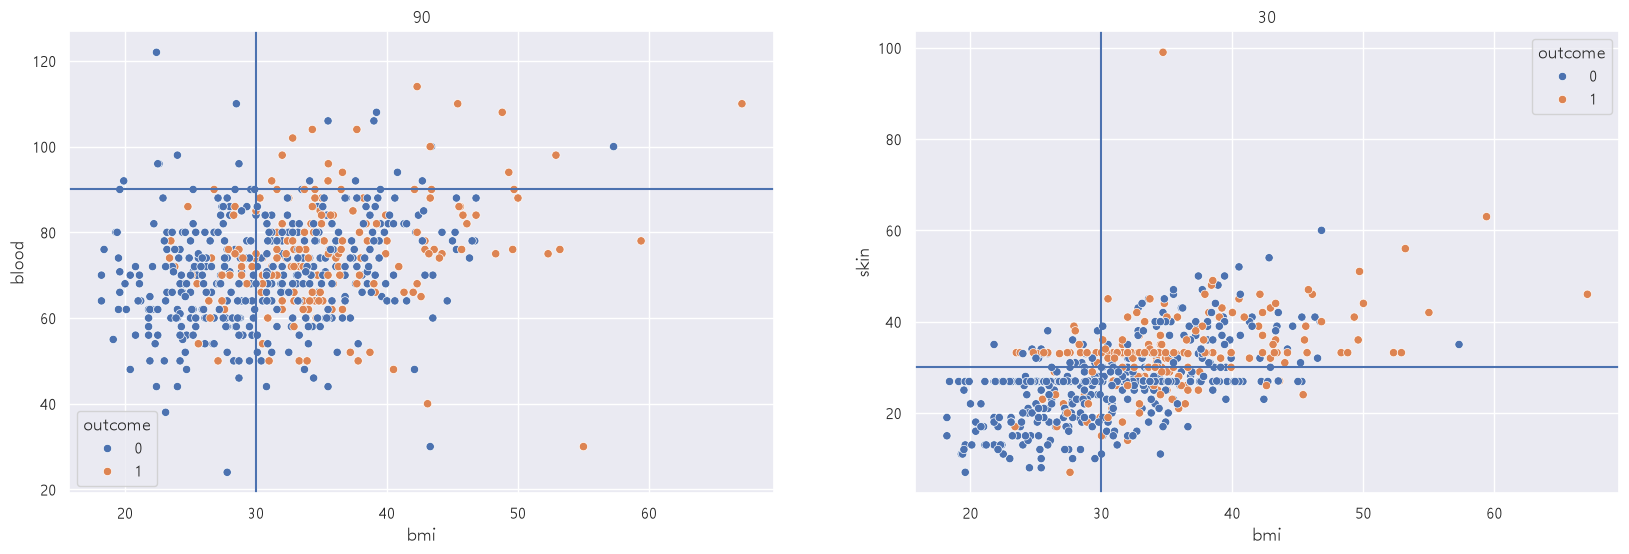

In [37]:
sub_cols = ["blood","skin"]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
sns.scatterplot(x="bmi", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[5], color='b')
axes[0].axhline(nomal_val[2], color='b')
axes[0].set_title(f"{nomal_val[2]}")

sns.scatterplot(x="bmi", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[5], color='b')
axes[1].axhline(nomal_val[3], color='b')
axes[1].set_title(f"{nomal_val[3]}")

plt.show()

### pregnancies & blood

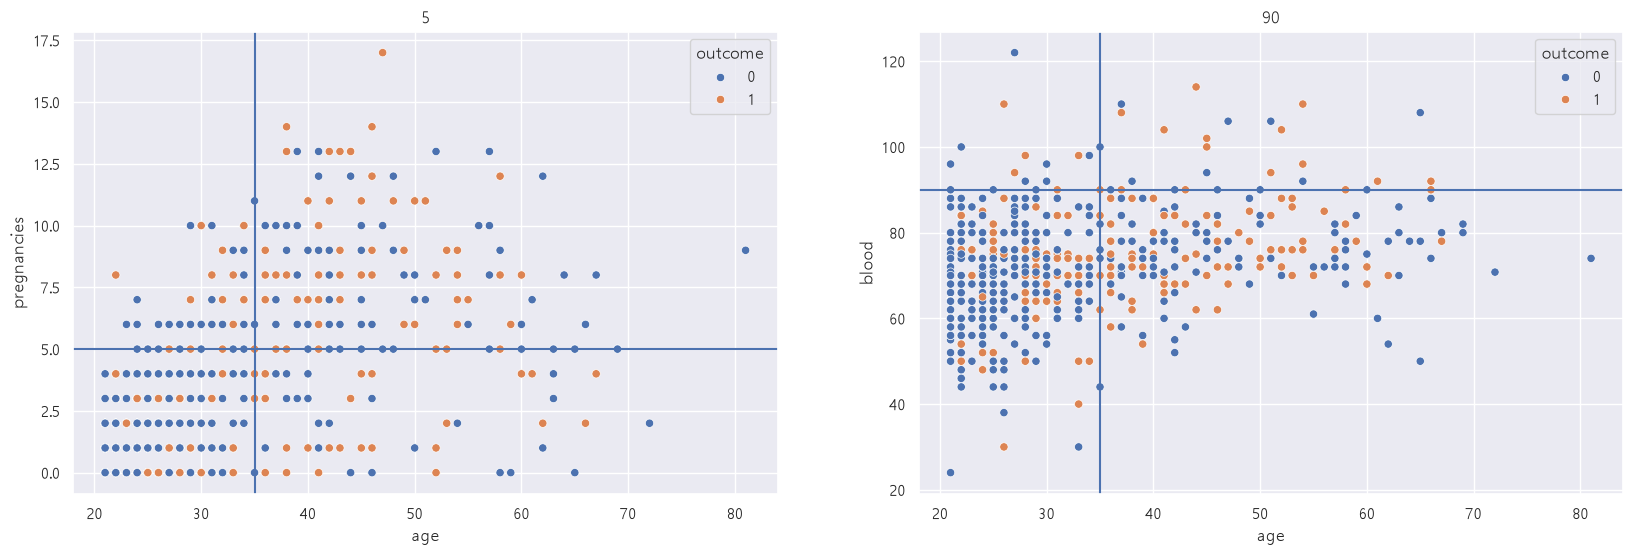

In [38]:
sub_cols = ["pregnancies","blood"]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
sns.scatterplot(x="age", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[7], color='b')
axes[0].axhline(nomal_val[0], color='b')
axes[0].set_title(f"{nomal_val[0]}")

sns.scatterplot(x="age", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[7], color='b')
axes[1].axhline(nomal_val[2], color='b')
axes[1].set_title(f"{nomal_val[2]}")

plt.show()

In [39]:
train.describe()

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age,outcome
count,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,3.832792,120.875573,72.099693,28.864335,146.847919,32.295098,0.471456,33.147727,0.311688
std,3.406302,30.203676,12.519718,8.995946,82.588534,6.856495,0.335874,11.775236,0.463560
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,115.000000,27.575000,0.245000,24.000000,0.000000
50%,3.000000,116.500000,72.000000,27.000000,121.627193,32.000000,0.372500,29.000000,0.000000
75%,6.000000,139.000000,80.000000,33.208633,200.000000,35.925000,0.607750,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.420000,81.000000,1.000000


### 아웃라이어 제거

In [40]:
alist = [1,2,3]
blist = [4,5]
alist.append(blist)
print(alist)

[1, 2, 3, [4, 5]]


In [41]:
alist = [1,2,3]
blist = [4,5]
alist.extend(blist)
print(alist)

[1, 2, 3, 4, 5]


In [42]:
del_idx_list = []

* **pregnancies >= 15**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7414

In [43]:
traincp = train.copy()
idx_list = traincp[traincp['pregnancies'] >= 15].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( idx_list )
myscore222(traincp)

[484]
RandomForestClassifier
acc : 0.8537  f1 : 0.7692  precision : 0.8333  recall : 0.7143
[[75  6]
 [12 30]]


RandomForestClassifier(random_state=1234)

* **skin >= 90**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7414 (pregnancies)
* f1 : 0.7547 (skin)

In [44]:
traincp = train.copy()
idx_list = traincp[traincp['skin'] >= 90].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( idx_list )
myscore222(traincp)

[484, 234]
RandomForestClassifier
acc : 0.8537  f1 : 0.7353  precision : 0.8065  recall : 0.6757
[[80  6]
 [12 25]]


RandomForestClassifier(random_state=1234)

* **insulin	 >= 700**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7414 (pregnancies)
* f1 : 0.7547 (skin)
* f1 : 0.7778 (insulin)

In [45]:
traincp = train.copy()
idx_list = traincp[traincp['insulin'] >= 700].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( idx_list )
myscore222(traincp)

[484, 234, 236]
RandomForestClassifier
acc : 0.8455  f1 : 0.7246  precision : 0.7812  recall : 0.6757
[[79  7]
 [12 25]]


RandomForestClassifier(random_state=1234)

* **bmi	 >= 60**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7414 (pregnancies)
* f1 : 0.7547 (skin)
* f1 : 0.7778 (insulin)
* f1 : 0.7556 (bmi)

In [46]:
traincp = train.copy()
idx_list = traincp[traincp['bmi'] >= 60].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( idx_list )
myscore222(traincp)

[484, 234, 236, 80]
RandomForestClassifier
acc : 0.8618  f1 : 0.7385  precision : 0.8000  recall : 0.6857
[[82  6]
 [11 24]]


RandomForestClassifier(random_state=1234)

* **원본적용 : outlier 전부 삭제**

In [47]:
train = train.drop( del_idx_list )
model = myscore222(traincp)

RandomForestClassifier
acc : 0.8618  f1 : 0.7385  precision : 0.8000  recall : 0.6857
[[82  6]
 [11 24]]


## **3차점수**

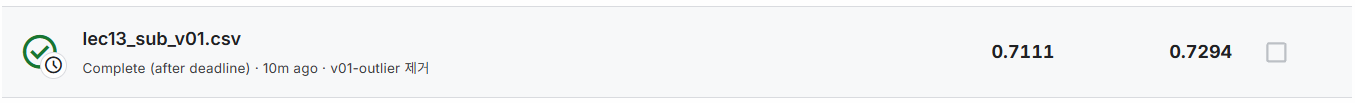

In [48]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v01.csv', index=False)

# 교차검증

In [49]:
X = train.drop(columns=['outcome'])
y = train['outcome']
model =  RandomForestClassifier (n_estimators=100,random_state=1234)
myparam = {"n_estimators"      : [100,200,300],
           "min_samples_split" : [2,3,4],
           "min_samples_leaf"  : [1,2,3]
          }

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
gcv_model = GridSearchCV(model, param_grid=myparam, scoring="f1", refit=True, cv=kf)
gcv_model.fit(X, y)

print(gcv_model.best_params_)
print(gcv_model.best_score_)

{'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
0.8001679528860987


## **4차점수**
* 튜닝 후 오버피팅 됨

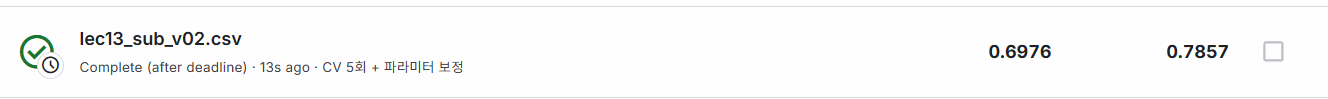

In [50]:
pred = gcv_model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v02.csv', index=False)

# 앙상블

In [51]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

model1 = GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=1212, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)
model2 = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=1212, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0, verbose=-1)
model3 = RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       n_estimators=100, n_jobs=-1, oob_score=False,
                       random_state=1212, verbose=0, warm_start=False)

In [52]:
vt_model = VotingClassifier(
    estimators=[
        ("gb"  , model1),
        ("lgbm"  , model2),
        ("rf" , model3)
    ],
    voting="hard"  #soft
)
model = myscore222(train, model=vt_model)

VotingClassifier
acc : 0.8862  f1 : 0.7941  precision : 0.8710  recall : 0.7297
[[82  4]
 [10 27]]


## **5차점수**

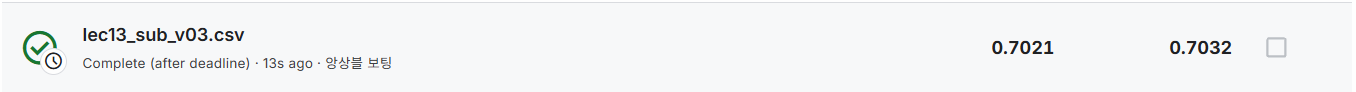

In [53]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v03.csv', index=False)

# **튜닝2차**

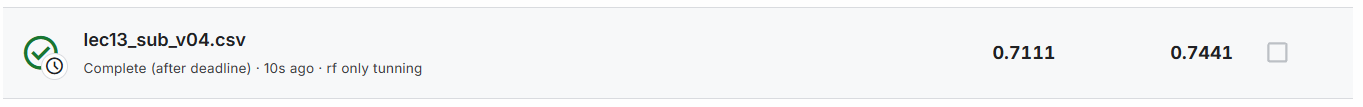

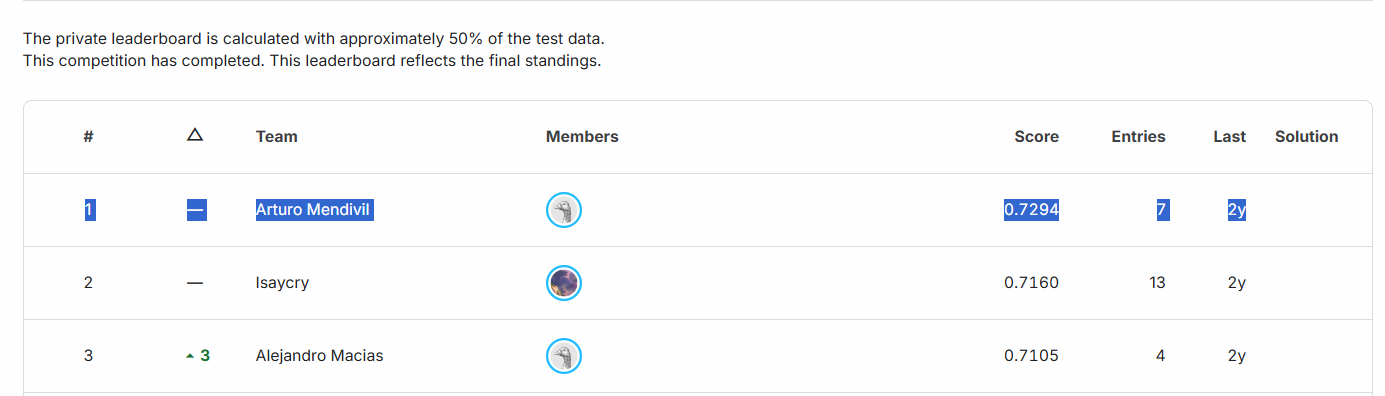

In [54]:
rf = RandomForestClassifier(n_estimators=300, random_state=1234, max_depth=20, min_samples_split=3, min_samples_leaf=1)
model = myscore222(traincp, model=rf)

RandomForestClassifier
acc : 0.8862  f1 : 0.7742  precision : 0.8889  recall : 0.6857
[[85  3]
 [11 24]]


### **6차점수**

In [55]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v04.csv', index=False)

# **[임계치 강제 조정]**
* Binarizer : Threshold를 OO으로 잡고, 보다크면 1로 이하는 0으로 바꿈

In [63]:
X = train.drop(columns=['outcome'])
y = train['outcome']
X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.2, random_state=1234, shuffle=True)

model = RandomForestClassifier(n_estimators=300, random_state=1234, max_depth=20, min_samples_split=3, min_samples_leaf=1)
model.fit(X_train7, y_train7)
pred = model.predict(X_test3)

#-------------------------------------------------pred
acc       = accuracy_score(y_test3, pred)
f1        = f1_score(y_test3, pred)
precision = precision_score(y_test3, pred)
recall    = recall_score(y_test3, pred)    
print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )

cm = confusion_matrix(y_test3, pred)
print( cm )

#-------------------------------------------------proba
proba = model.predict_proba(X_test3)
proba_p = proba[:,1]


acc : 0.8699  f1 : 0.7714  precision : 0.8182  recall : 0.7297
[[80  6]
 [10 27]]


In [66]:
for th in [0.5, 0.49, 0.48, 0.47, 0.46, 0.45, 0.44  ] :
    bz = Binarizer(threshold=th)
    bz.fit(proba_p.reshape(-1, 1) )
    pred = bz.transform(proba_p.reshape(-1, 1) )
    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    print( f"acc : {acc:.4f}  f1 : {f1:.4f} " )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )

acc : 0.8699  f1 : 0.7714 
[[80  6]
 [10 27]]
acc : 0.8780  f1 : 0.7887 
[[80  6]
 [ 9 28]]
acc : 0.8780  f1 : 0.7887 
[[80  6]
 [ 9 28]]
acc : 0.8780  f1 : 0.7887 
[[80  6]
 [ 9 28]]
acc : 0.8862  f1 : 0.8056 
[[80  6]
 [ 8 29]]
acc : 0.8943  f1 : 0.8219 
[[80  6]
 [ 7 30]]
acc : 0.8943  f1 : 0.8219 
[[80  6]
 [ 7 30]]


## **7차점수**

In [67]:
proba = model.predict_proba(test)
proba_p = proba[:,1]

bz = Binarizer(threshold=0.44)
bz.fit(proba_p.reshape(-1, 1) )
pred = bz.transform(proba_p.reshape(-1, 1) )

In [70]:
pred = pred.reshape(-1)
pred[:10]

array([0., 0., 1., 1., 0., 0., 0., 1., 0., 0.])

In [71]:
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v05.csv', index=False)